# CTGF calcium imaging_To quantify how the neuronal response type varies between behaviors
### (activated, inhibited, non-responsive)

By Debora Masini 2025

#### Probabilities that cells remain within same response CLASS accross behaviors
-  Pairwise transition matrices for all behavior pairs
-  Per-behavior outgoing transition summaries
-  Global pooled transition matrix
-  Stability (stay probability) and change metrics
-  graphs (matrix heatmaps, barplots)
-  statistical tests (chi² test for class distributions)

In [ ]:
import numpy as np
import pandas as pd
import itertools

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact

from pathlib import Path
import warnings
import os

In [1]:
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy_version)

matplotlib: 3.9.0
seaborn: 0.13.2
scipy: 1.13.1


### step 1) are response mode classifications stable across behaviors?
Taking per-cell classifications across behaviors (activated / inhibited / non-responsive) and treating them like “states,” then estimating how often a cell’s state in behavior A maps to its state in behavior B. Do this for every unordered pair of behaviors, then aggregate those pairwise transitions into per-behavior and global transition matrices, plus run independence tests (chi-square, Fisher fallback) on each pair’s contingency table.

In [ ]:
# Load data
ANALYSIS_DIR = Path(r"...\python_analysis_results\results\collected_summary_files")
df = pd.read_csv(ANALYSIS_DIR / "all_stats.csv") # from the classification script analysis ("activated", "inhibited", "non-responsive") 


desired_behavs = ["during buttsniff same sex", "during buttsniff opposite sex", "during nose poke", "during slot poke"] # which behaviors to include in the analysis
behaviors = [b for b in desired_behavs if b in df["behavior"].unique()] # Restrict to behaviors available in data
valid_classes = ["activated", "inhibited", "non-responsive"] # the 3 types of response a cell can have during the behavior

# Function
def compute_transition_statistics(df, valid_classes, behaviors=None, do_plots=True, figsize=(5, 5), out_dir=None):
    """
    Compute transition statistics across all unordered behavior pairs.
    - Collision detection: warns if multiple classifications exist for cell×behavior.
    - Division-by-zero protection.
    """
    # Integrity check
    dup_mask = df.duplicated(subset=["cell", "behavior"])
    if dup_mask.any():
        collisions = df[df.duplicated(subset=["cell", "behavior"], keep=False)]
        warnings.warn(
            f"Collision detected: multiple entries for the same cell×behavior.\n"
            f"Rows:\n{collisions}"
        )

    df_wide = df.pivot_table(index="cell", columns="behavior", values="classification", aggfunc="first") # Pivot table, cell × behavior classification

    # Keep only selected behaviors
    if behaviors is not None:
        df_wide = df_wide.reindex(columns=behaviors)
        behaviors = [b for b in behaviors if b in df_wide.columns]
    else:
        behaviors = df_wide.columns.tolist()

    # Pairwise transition matrices
    pairwise = {}
    stats_results = {}

    for b1, b2 in itertools.combinations(behaviors, 2):
        # each pairwise analysis should be on the intersection of cells that have labels for both behaviors.
        pairs = df_wide[[b1, b2]].dropna() #Keep only cells that have both behaviors labeled
        if pairs.empty:
            continue

        # Raw counts, contingency table of class-to-class transitions 3x3
            # rows = class in behavior b1 (source)
            # cols = class in behavior b2 (dest)
            # values = number of cells
        counts = pairs.value_counts().unstack(fill_value=0)
        counts = counts.reindex(index=valid_classes, columns=valid_classes, fill_value=0)

        # Probabilities (row-wise normalized)
        row_sums = counts.sum(axis=1)
        probs = counts.div(row_sums.replace(0, np.nan), axis=1) # convert counts to row-normalized probabilities

        pairwise[(b1, b2)] = probs

        observed = counts.values # Statistical Test: Chi-square or Fisher exact (as fall back)
        chi2, p_chi, dof, expected = chi2_contingency(observed) # Chi-square assumptions: expected frequencies >= 5

        use_fisher = False
        if expected.min() < 5: # should not happen given data set size, but better safe than sorrow.
            use_fisher = True
            odds, p_fisher = fisher_exact(observed)
        else:
            p_fisher = np.nan
            odds = np.nan

        stats_results[(b1, b2)] = {
            "chi2": chi2,
            "pvalue_chi": p_chi,
            "pvalue_fisher": p_fisher if use_fisher else None,
            "oddsratio_fisher": odds if use_fisher else None,
            "dof": dof,
            "expected": expected,
            "observed": observed,
            "used_fisher": use_fisher
        }

    
    per_behavior = {} # Per-behavior aggregated transitions
    
    # For a given source behavior b_source, gather all pairwise transition matrices where b_source participates.
    for b_source in behaviors:
        collected = []
        for (b1, b2), mat in pairwise.items():
            mat = mat.reindex(index=valid_classes, columns=valid_classes) # Reindex for consistent dimension
            if b1 == b_source:
                collected.append(mat)
            elif b2 == b_source:
                collected.append(mat.T.reindex(index=valid_classes, columns=valid_classes))
        if collected:
            per_behavior[b_source] = pd.concat(collected).groupby(level=0).mean()

    
    all_pairs = [] # Global transitions

    for (b1, b2) in pairwise:
        tmp = df_wide[[b1, b2]].dropna().rename(columns={b1: "source", b2: "dest"}) # pool all (b1,b2) pairs into one big dataset
        all_pairs.append(tmp)

    if all_pairs: #estimating a transition frequency weighted by number of pairwise comparisons. in the future could do a Cell-weighted stability test.
        all_pairs = pd.concat(all_pairs)

        global_counts = all_pairs.value_counts().unstack(fill_value=0)
        global_counts = global_counts.reindex(index=valid_classes, columns=valid_classes, fill_value=0)

        row_sums = global_counts.sum(axis=1)
        global_matrix = global_counts.div(row_sums.replace(0, np.nan), axis=1)

        stability = pd.Series( # diagonal
            {cls: global_matrix.loc[cls, cls] for cls in valid_classes},
            name="P(stay)"
        )
        change = 1 - stability
    else:
        global_matrix = stability = change = None

    # Plots
    if do_plots and global_matrix is not None:

        # Global transition matrix
        plt.figure(figsize=figsize)
        sns.heatmap(global_matrix, annot=True, cmap="viridis", vmin=0, vmax=1)
        plt.title("Global Transition Probability Matrix")
        plt.tight_layout()
        if out_dir is not None:
            plt.savefig(out_dir / "global_transition_matrix.svg")
        plt.show()

        # Stability (Pstay)
        plt.figure(figsize=(3, 4))
        stability.plot(kind="bar", color='grey')
        plt.ylim(0, 1)
        plt.title("Stability Probability per Class")
        plt.ylabel("P(stay)")
        plt.tight_layout()

        if out_dir is not None:
            plt.savefig(out_dir / "stability.svg")
        plt.show()

        # Change (Pchange)
        plt.figure(figsize=(3, 4))
        change.plot(kind="bar", color="grey")
        plt.ylim(0, 1)
        plt.title("Change Probability per Class")
        plt.ylabel("P(change)")
        plt.tight_layout()

        if out_dir is not None:
            plt.savefig(out_dir / "change.svg")
        plt.show()

    # Save summary tables
    if out_dir is not None:
        if global_matrix is not None:
            global_matrix.to_csv(out_dir / "global_transition_matrix.csv")
            stability.to_csv(out_dir / "stability.csv")
            change.to_csv(out_dir / "change.csv")
        # Save pairwise stats
        stats_df = []
        for (b1, b2), s in stats_results.items():
            row = {"behavior_1": b1, "behavior_2": b2}
            row.update(s)
            stats_df.append(row)
        pd.DataFrame(stats_df).to_csv(out_dir / "pairwise_stats.csv", index=False)

    return {
        "pairwise": pairwise,
        "per_behavior": per_behavior,
        "global_matrix": global_matrix,
        "stability": stability,
        "change": change,
        "stats": stats_results
    }

results = compute_transition_statistics( df, valid_classes=valid_classes, behaviors=behaviors, do_plots=True, out_dir=ANALYSIS_DIR)

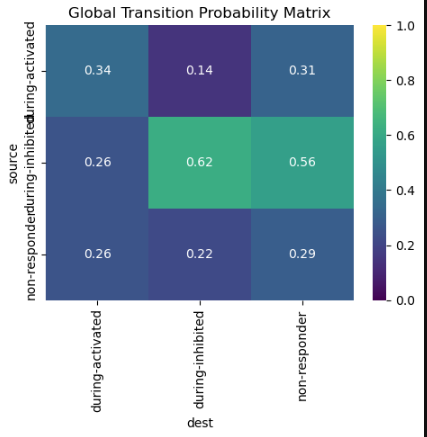

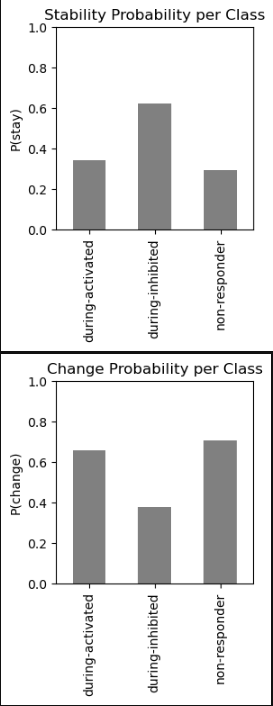

#### General explainer for **Global Transition Matrix**
- Global matrix shows the probability of moving from each class (rows) to another class (columns):
Source class	P(stay)	Notes
during-activated	0.341	Low stability — activated cells often change state.
during-inhibited	0.623	Highest stability across classes.
non-responder	0.293	Mostly unstable; shifts frequently to other classes.
- Observations: Inhibited neurons show the strongest cross-behavior consistency. Activated and non-responder cells frequently transition to other response modes. Row-sum normalization is correct; no division-by-zero problems.

### step 2) Vs null expectation
Loading above-saved outputs, then building a “stability vs null expectation” summary per class (activated / inhibited / non-responsive). Compare the diagonal of the global transition matrix (observed “stay” probability) to what one would expect if labels were paired at random **given overall class prevalence**.


In [ ]:
# Analysis Script: Expected vs. Observed Stability

raw_df_path = ANALYSIS_DIR / "all_stats.csv"
global_mat_path = ANALYSIS_DIR / "global_transition_matrix.csv"
pairwise_stats_path = ANALYSIS_DIR / "pairwise_stats.csv"

df = pd.read_csv(raw_df_path)
global_mat = pd.read_csv(global_mat_path)
pairwise = pd.read_csv(pairwise_stats_path)

# Compute population fractions for each classification. Take each cell’s classification frequency across behaviors
pop_counts = df.groupby("classification").size()
pop_fraction = pop_counts / pop_counts.sum() 

# sanity, ensure all classes present
for cls in valid_classes:
    pop_fraction.loc[cls] = pop_fraction.get(cls, 0)

# Extract observed P(stay) from global transition matrix
global_mat = global_mat.set_index("source")
observed_stay = pd.Series(
    {cls: global_mat.loc[cls, cls] for cls in valid_classes},
    name="P(stay)_observed"
)

# consider permutation in the future. simpler strategy used here.
expected_stay = pop_fraction.rename("P(stay)_expected_null") # Expected stability under random transitions (equal to the population fraction)
stay_diff = (observed_stay - expected_stay).rename("Observed - Expected") #  Difference between observed and expected

# Build summary table
summary = pd.concat([observed_stay, expected_stay, stay_diff], axis=1)
summary.index.name = "classification"

print("\n===== Stability Analysis Summary =====\n")
print(summary)
print("\nPopulation fractions:\n", pop_fraction)
print("\nObserved P(stay):\n", observed_stay)
print("\nExpected null P(stay):\n", expected_stay)
print("\nDifference (Observed - Expected):\n", stay_diff)

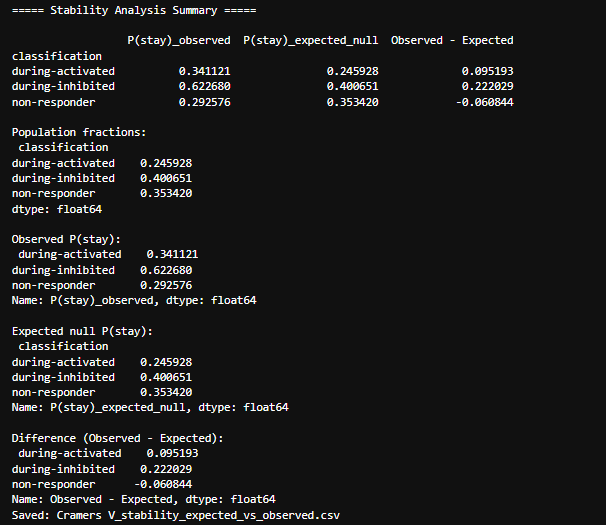

In [ ]:
# segment to reorganize folders deleted.

In [ ]:
# script end